In [2]:
from pyspark.sql import SparkSession
import os
import pyspark.sql.functions as F
from pyspark.sql.types import IntegerType
import json

In [2]:
access_key = os.getenv("S3_ACCESS_KEY")
secret_key = os.getenv("S3_SECRET_KEY") 

spark = SparkSession.builder \
    .master("spark://master:7077")\
    .appName("Anomaly Detection")\
    .config('spark.jars.packages', 'org.apache.hadoop:hadoop-aws:3.4.1,org.apache.hadoop:hadoop-common:3.4.1')\
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")\
    .config("spark.sql.execution.arrow.pyspark.fallback.enabled", "false")\
    .config('spark.hadoop.fs.s3a.aws.credentials.proviAnvoder', 'org.apache.hadoop.fs.s3a.SimpleAWSCredentialsProvider')\
    .config('spark.hadoop.fs.s3a.access.key', access_key)\
    .config('spark.hadoop.fs.s3a.secret.key', secret_key)\
    .config('spark.hadoop.fs.s3a.endpoint', 'https://cloud-areapd.pd.infn.it:5210')\
    .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem") \
    .config("spark.hadoop.fs.s3a.metadatastore.impl", "org.apache.hadoop.fs.s3a.s3guard.NullMetadataStore") \
    .config("spark.hadoop.fs.s3a.path.style.access", "true") \
    .config("spark.hadoop.fs.s3a.connection.ssl.enabled","false") \
    .config("com.amazonaws.sdk.disableCertChecking","true") \
    .getOrCreate()

:: loading settings :: url = jar:file:/usr/local/spark/jars/ivy-2.5.3.jar!/org/apache/ivy/core/settings/ivysettings.xml
Ivy Default Cache set to: /home/ubuntu/.ivy2.5.2/cache
The jars for the packages stored in: /home/ubuntu/.ivy2.5.2/jars
org.apache.hadoop#hadoop-aws added as a dependency
org.apache.hadoop#hadoop-common added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-ea58d0d3-2b7d-4778-8b76-a41fcabcfbd7;1.0
	confs: [default]
	found org.apache.hadoop#hadoop-aws;3.4.1 in central
	found software.amazon.awssdk#bundle;2.24.6 in central
	found org.wildfly.openssl#wildfly-openssl;1.1.3.Final in central
	found org.apache.hadoop#hadoop-common;3.4.1 in central
	found org.apache.hadoop.thirdparty#hadoop-shaded-protobuf_3_25;1.3.0 in central
	found org.apache.hadoop#hadoop-annotations;3.4.1 in central
	found org.apache.hadoop.thirdparty#hadoop-shaded-guava;1.3.0 in central
	found com.google.guava#guava;27.0-jre in central
	found com.google.guava#failureacce

## **Anomaly detection 1**

This section identifies anomalies in the dataset by tracking the state switches of the compressor engines and correlating them with the status of other machine sensors.

## Data Loading and Preprocessing

Read the raw Parquet dataset from the S3 bucket, parse timestamps, and align the DataFrame schema for the subsequent transformations.

In [3]:
df_spark = spark.read.parquet("s3a://MAPDB-Group5/data_parquet")

In [4]:
df_spark = df_spark.withColumn(
    "when",
    F.timestamp_millis(df_spark.when)
)

df_spark = df_spark.withColumn(
    "timestamp_bucket",
    F.date_trunc("minute", "when")
)

df_spark.printSchema()

root
 |-- when: timestamp (nullable = true)
 |-- hwid: string (nullable = true)
 |-- metric: string (nullable = true)
 |-- value: integer (nullable = true)
 |-- timestamp_bucket: timestamp (nullable = true)



In [5]:
continuous_metrics = [
    'E1', 'E2',
    'S19', 'S37', 'S39', 'S40', 'S41', 'S42', 'S43', 'S45', 'S46', 'S47', 'S49', 'S50',
    'S69', 'S70', 'S71', 'S72', 'S80', 'S81', 'S83', 'S86', 'S90', 'S94', 'S97',
    'S100', 'S101', 'S102', 'S106', 'S107', 'S108', 'S109', 'S110',
    'S122', 'S124', 'S125', 'S126', 'S128', 'S129',
    'S137', 'S138', 'S140', 'S143', 'S147',
    'S151', 'S154', 'S157', 'S158', 'S159',
    'S163', 'S164', 'S165', 'S166', 'S167',
    'S178', 'S180', 'S181'
]

df_aggregated = (
    df_spark.groupBy("timestamp_bucket", "hwid", "metric")
      .agg(
          F.coalesce(
              F.mean(F.when(F.col("metric").isin(continuous_metrics), F.col("value"))),
              F.max(F.col("value"))
          ).alias("aggregated_value")
      )
)

df_aggregated.printSchema()

root
 |-- timestamp_bucket: timestamp (nullable = true)
 |-- hwid: string (nullable = true)
 |-- metric: string (nullable = true)
 |-- aggregated_value: double (nullable = true)



## **Anomaly detection 1: Task 1 (Engine State Switches)**

Calculate the total number of ON/OFF state switches for each compressor engine within 1-hour tumbling windows.

In [6]:
df_anomaly1 = df_aggregated.withColumn(
    "hour_bucket", 
    F.date_trunc("hour", F.col("timestamp_bucket"))
)

df_anomaly1.printSchema()

root
 |-- timestamp_bucket: timestamp (nullable = true)
 |-- hwid: string (nullable = true)
 |-- metric: string (nullable = true)
 |-- aggregated_value: double (nullable = true)
 |-- hour_bucket: timestamp (nullable = true)



In [7]:
target_metrics = ["S117", "S118", "S169", "S170"]

In [ ]:
from pyspark.sql.window import Window

w = Window.partitionBy("hwid", "metric").orderBy("timestamp_bucket")

df_hourly_frequency = (
    df_anomaly1.filter(F.col("metric").isin(target_metrics))
    .withColumn("prev_val", F.lag("aggregated_value", 1).over(w))
    .withColumn(
        "is_switch",
        F.when(
            F.col("prev_val").isNotNull() & (F.col("aggregated_value") != F.col("prev_val")),
            1,
        ).otherwise(0),
    )
    .groupBy("hour_bucket", "hwid", "metric")
    .agg(F.sum("is_switch").alias("total_state_switches"))
)

df_hourly_frequency.printSchema()


root
 |-- hour_bucket: timestamp (nullable = true)
 |-- hwid: string (nullable = true)
 |-- metric: string (nullable = true)
 |-- total_state_switches: integer (nullable = true)



In [10]:
df_histogram_data = df_hourly_frequency \
                            .where( F.col("metric").isin(target_metrics) )\
                            .groupBy("total_state_switches") \
                            .count() \
                            .orderBy("total_state_switches")

df_histogram_data.printSchema()

root
 |-- total_state_switches: integer (nullable = true)
 |-- count: long (nullable = false)



In [11]:
df_histogram_data.describe().show()

+-------+--------------------+------------------+
|summary|total_state_switches|             count|
+-------+--------------------+------------------+
|  count|                  13|                13|
|   mean|                 6.0|4015.3846153846152|
| stddev|  3.8944404818493075| 8972.690692117401|
|    min|                   0|                 6|
|    max|                  12|             33028|
+-------+--------------------+------------------+



In [12]:
import pandas as pd
import numpy as np

pdf = df_histogram_data.toPandas()

# Sort the df 
pdf = pdf.sort_values(by="total_state_switches") 

# Calculate Total, Min, and Max
total_count = pdf['count'].sum()
min_val = pdf['total_state_switches'].min()
max_val = pdf['total_state_switches'].max()

mean_val = np.average(pdf['total_state_switches'], weights=pdf['count'])
stddev_val = np.sqrt( np.average((pdf['total_state_switches'] - mean_val)**2, weights=pdf['count']) )

# Calculate Mode
mode_val = pdf.loc[pdf['count'].idxmax(), 'total_state_switches']

pdf["cum_sum"] = pdf["count"].cumsum()

median_val = pdf[pdf['cum_sum'] >= total_count / 2.0].iloc[0]['total_state_switches']
p95 = pdf[pdf["cum_sum"] >= total_count * 0.95].iloc[0]["total_state_switches"]


summary_df = pd.DataFrame([{
    'total_count': total_count,
    'min': min_val,
    'max': max_val,
    'mean': mean_val,
    'stddev': stddev_val,
    'median': median_val,
    '95% percentile': p95,
    'mode': mode_val
}])

# Display the final statistics
summary_df

,total_count,min,max,mean,stddev,median,95% percentile,mode
0,52200,0,12,0.992874,1.61462,0,4,0


In [13]:
# Free up some memory
del summary_df, stddev_val, total_count, min_val, max_val

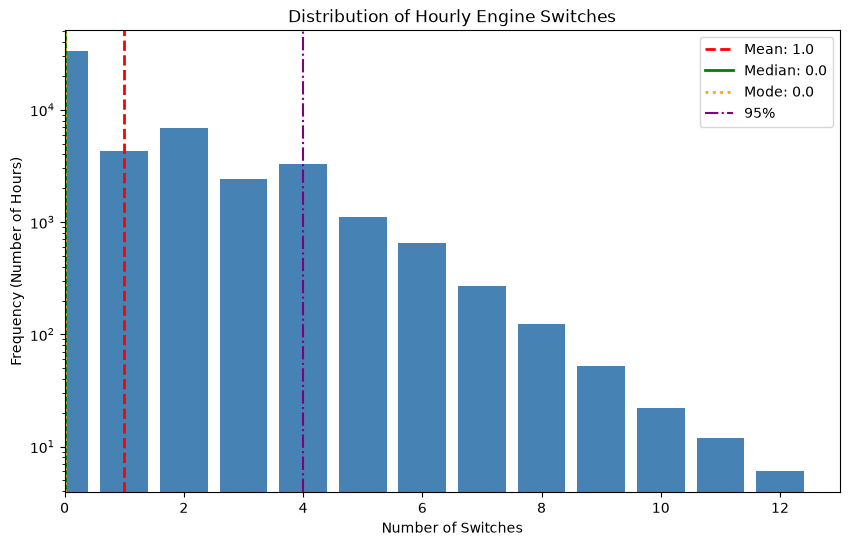

In [14]:
import matplotlib.pyplot as plt

# Figure size
plt.figure(figsize=(10, 6))

# Set the bars 
plt.bar(
    pdf['total_state_switches'], 
    pdf['count'], 
    color='steelblue', 
    width=0.8
)

plt.axvline(x=mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.1f}')
plt.axvline(x=median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.1f}')
plt.axvline(x=mode_val, color='orange', linestyle=':', linewidth=2, label=f'Mode: {mode_val:.1f}')
plt.axvline(x=p95, color='purple', linestyle='-.', linewidth=1.5, label='95%')


# Labels
plt.title('Distribution of Hourly Engine Switches')
plt.xlabel('Number of Switches')
plt.ylabel('Frequency (Number of Hours)')
plt.yscale("log")
plt.xlim([0, 13])
plt.legend() 

plt.show()

plt.close('all')

## **Anomaly detection 1: Task 2 (Sensor Correlation)**

Join the hourly engine switch counts with the average values of various sensor groups to discover hidden correlations that might indicate abnormal behaviors.

In [15]:
spark.conf.set("spark.sql.ansi.enabled", "false")

### General Settings

Define target metrics and sensor groups to structure the correlation analysis.

In [6]:


with open("metrics_engines.json", 'r') as file:

    loaded_metrics = json.load(file)

metric_groups = loaded_metrics["metric_groups"]
engine_labels = loaded_metrics["engine_labels"]

print("Available metric groups:")
for name, metrics in metric_groups.items():
    print(f"  \u2022 {name:20s}  ({len(metrics)} metrics: {', '.join(metrics.keys())})")

print("Engines metrics:")
for metrics, name in engine_labels.items():
    print(f"  \u2022 {name:20s}   metric: {metrics}")


Available metric groups:
  • temperatures          (8 metrics: S41, S39, S40, S49, S50, S45, S46, S47)
  • pressures             (6 metrics: S100, S101, S102, S157, S158, S159)
  • capacities            (4 metrics: S125, S181, S126, S43)
  • discharge_temps       (9 metrics: S109, S110, S165, S166, S106, S107, S108, S163, S164)
  • superheat_eev         (7 metrics: S81, S83, S86, S90, S138, S140, S143)
  • signals_valves        (7 metrics: S19, S37, S69, S70, S122, S178, S42)
  • power_energy          (2 metrics: E1, E2)
  • subcooling_misc       (9 metrics: S124, S180, S94, S97, S128, S129, S147, S151, S154)
Engines metrics:
  • Status Comp 1,1        metric: S117
  • Status Comp 2,1        metric: S118
  • Status Comp 1,2        metric: S169
  • Status Comp 2,2        metric: S170


### Helper Functions

Utility functions to programmatically pivot, join, correlate, and visualize the sensor data heatmaps.

In [18]:
def engines_switch_counts_df(metric_groups, SELECTED_GROUP, target_metrics):

    selected_metrics = metric_groups[SELECTED_GROUP]
    sensor_codes     = list(selected_metrics.keys())

    print(f"Correlating each engine against group '{SELECTED_GROUP}':")
    print(f"  Sensors: {sensor_codes}\n")

# Pivot data
    df_engine_wide = (
        df_hourly_frequency
        .filter(F.col("metric").isin(target_metrics))
        .groupBy("hour_bucket", "hwid")
        .pivot("metric", target_metrics)
        .agg(F.first("total_state_switches"))
    )

# Pivot data
    df_sensors_wide = (
        df_anomaly1
        .filter(F.col("metric").isin(sensor_codes))
        .groupBy("hour_bucket", "hwid")
        .pivot("metric", sensor_codes)
        .agg(F.avg("aggregated_value"))
    )

# Join tables
    df_joined = df_engine_wide.join(
        df_sensors_wide,
        on=["hour_bucket", "hwid"],
        how="inner"
    )

    return df_joined, selected_metrics, sensor_codes

In [19]:

def corr_df(sensor_codes, df_joined):

    corr_exprs = []
    for eng in target_metrics:
        for s in sensor_codes:
            alias = f"corr_{eng}_vs_{s}"
            corr_exprs.append(F.corr(eng, s).alias(alias))

    # Apply the expressions
    df_correlation = df_joined.groupBy("hwid").agg(*corr_exprs)

    return df_correlation

In [20]:
import matplotlib.pyplot as plt
import matplotlib


def engine_sensors_heatmap(pandas_pdf_corr, sensor_codes, selected_metrics):

    rows = []
    for eng in target_metrics:
        row = {}
        for s in sensor_codes:
            col_name = f"corr_{eng}_vs_{s}"
            row[selected_metrics[s]] = pandas_pdf_corr[col_name].mean()
        rows.append(row)

    pdf_heatmap = pd.DataFrame(rows, index=[engine_labels[e] for e in target_metrics])

    # Plot
    fig, ax = plt.subplots(figsize=(max(8, len(sensor_codes) * 1.5), 5))

    data = pdf_heatmap.values.astype(float)
    cmap = plt.cm.RdBu_r
    norm = matplotlib.colors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

    im = ax.imshow(data, cmap=cmap, norm=norm, aspect="auto")

    # Axes labels
    ax.set_xticks(range(len(pdf_heatmap.columns)))
    ax.set_xticklabels(pdf_heatmap.columns, rotation=45, ha="right", fontsize=9)
    ax.set_yticks(range(len(pdf_heatmap.index)))
    ax.set_yticklabels(pdf_heatmap.index, fontsize=10)

    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data[i, j]
            if np.isnan(val):
                txt = "n/a"
            else:
                txt = f"{val:.2f}"
            text_color = "white" if abs(val if not np.isnan(val) else 0) > 0.55 else "black"
            ax.text(j, i, txt, ha="center", va="center",
                    fontsize=9, color=text_color, fontweight="bold")

    cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
    cbar.set_label("Pearson r", fontsize=10)

    ax.set_title(
        f"Correlation: engine switch frequency vs '{SELECTED_GROUP}' metrics\n"
        f"(averaged across devices)",
        fontsize=12, fontweight="bold"
    )

    plt.tight_layout()
    plt.show()
    plt.close("all")


In [21]:

def per_device_heatmap(engine, sensor_codes, selected_metrics, pandas_pdf_corr):

    eng_corr_cols = [f"corr_{engine}_vs_{s}" for s in sensor_codes]

    pdf_eng = pandas_pdf_corr[["hwid"] + eng_corr_cols].copy()
    pdf_eng = pdf_eng.set_index("hwid")
    pdf_eng.columns = [selected_metrics[s] for s in sensor_codes]

    fig, ax = plt.subplots(figsize=(max(8, len(sensor_codes) * 1.5), max(4, len(pdf_eng) * 0.8)))

    data = pdf_eng.values.astype(float)

    cmap = plt.cm.RdBu_r
    norm = matplotlib.colors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

    im = ax.imshow(data, cmap=cmap, norm=norm, aspect="auto")

    ax.set_xticks(range(len(pdf_eng.columns)))
    ax.set_xticklabels(pdf_eng.columns, rotation=45, ha="right", fontsize=9)
    ax.set_yticks(range(len(pdf_eng.index)))
    ax.set_yticklabels(pdf_eng.index, fontsize=10)

    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data[i, j]
            if np.isnan(val):
                txt = "n/a"
            else:
                txt = f"{val:.2f}"
            text_color = "white" if abs(val if not np.isnan(val) else 0) > 0.55 else "black"
            ax.text(j, i, txt, ha="center", va="center",
                    fontsize=9, color=text_color, fontweight="bold")

    cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
    cbar.set_label("Pearson r", fontsize=10)

    ax.set_title(
        f"Per-device correlations for engine {engine} "
        f"({engine_labels[engine]})\n"
        f"vs '{SELECTED_GROUP}' metrics",
        fontsize=12, fontweight="bold"
    )

    plt.tight_layout()
    plt.show()
    plt.close("all")


### Temperature metrics analysis

In [22]:
SELECTED_GROUP = "temperatures"

In [23]:
# Pivot data
df_joined, selected_metrics, sensor_codes = engines_switch_counts_df(
    metric_groups, 
    SELECTED_GROUP, 
    target_metrics
)

Correlating each engine against group 'temperatures':
  Sensors: ['S41', 'S39', 'S40', 'S49', 'S50', 'S45', 'S46', 'S47']



In [24]:
df_correlation = corr_df(sensor_codes, df_joined)

df_correlation.printSchema()

root
 |-- hwid: string (nullable = true)
 |-- corr_S117_vs_S41: double (nullable = true)
 |-- corr_S117_vs_S39: double (nullable = true)
 |-- corr_S117_vs_S40: double (nullable = true)
 |-- corr_S117_vs_S49: double (nullable = true)
 |-- corr_S117_vs_S50: double (nullable = true)
 |-- corr_S117_vs_S45: double (nullable = true)
 |-- corr_S117_vs_S46: double (nullable = true)
 |-- corr_S117_vs_S47: double (nullable = true)
 |-- corr_S118_vs_S41: double (nullable = true)
 |-- corr_S118_vs_S39: double (nullable = true)
 |-- corr_S118_vs_S40: double (nullable = true)
 |-- corr_S118_vs_S49: double (nullable = true)
 |-- corr_S118_vs_S50: double (nullable = true)
 |-- corr_S118_vs_S45: double (nullable = true)
 |-- corr_S118_vs_S46: double (nullable = true)
 |-- corr_S118_vs_S47: double (nullable = true)
 |-- corr_S169_vs_S41: double (nullable = true)
 |-- corr_S169_vs_S39: double (nullable = true)
 |-- corr_S169_vs_S40: double (nullable = true)
 |-- corr_S169_vs_S49: double (nullable = true)

In [25]:
pdf_corr = df_correlation.toPandas()

26/09/12 13:11:32 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


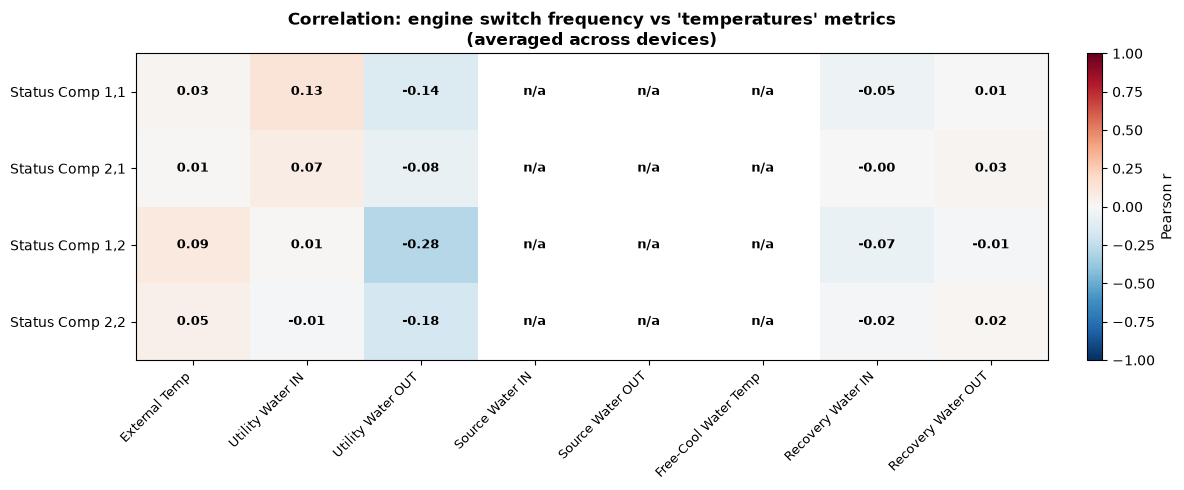

In [26]:
import pandas as pd
import numpy as np

engine_sensors_heatmap(pdf_corr, sensor_codes, selected_metrics)

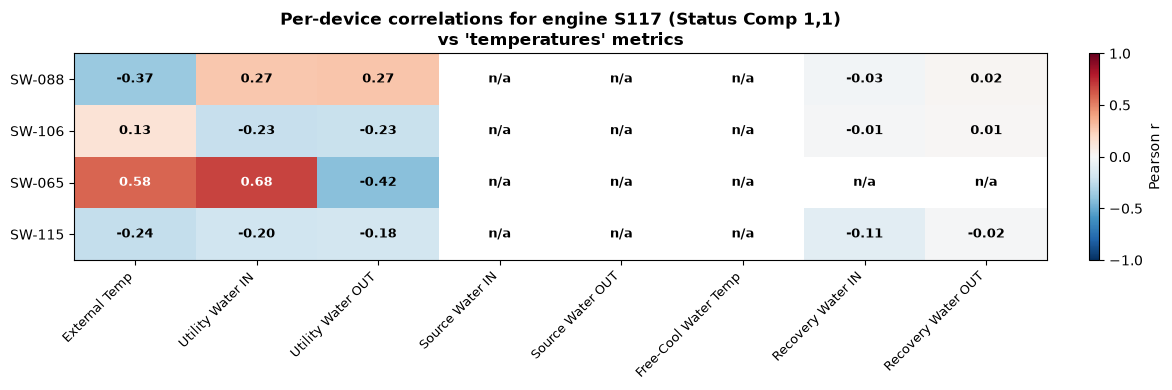

In [27]:
per_device_heatmap("S117", sensor_codes, selected_metrics, pdf_corr)

### Pressure metrics analysis

In [28]:
SELECTED_GROUP = "pressures"

In [29]:
# Pivot data
df_joined, selected_metrics, sensor_codes = engines_switch_counts_df(
    metric_groups, 
    SELECTED_GROUP, 
    target_metrics
)

Correlating each engine against group 'pressures':
  Sensors: ['S100', 'S101', 'S102', 'S157', 'S158', 'S159']



In [30]:
df_correlation = corr_df(sensor_codes, df_joined)

df_correlation.printSchema()

root
 |-- hwid: string (nullable = true)
 |-- corr_S117_vs_S100: double (nullable = true)
 |-- corr_S117_vs_S101: double (nullable = true)
 |-- corr_S117_vs_S102: double (nullable = true)
 |-- corr_S117_vs_S157: double (nullable = true)
 |-- corr_S117_vs_S158: double (nullable = true)
 |-- corr_S117_vs_S159: double (nullable = true)
 |-- corr_S118_vs_S100: double (nullable = true)
 |-- corr_S118_vs_S101: double (nullable = true)
 |-- corr_S118_vs_S102: double (nullable = true)
 |-- corr_S118_vs_S157: double (nullable = true)
 |-- corr_S118_vs_S158: double (nullable = true)
 |-- corr_S118_vs_S159: double (nullable = true)
 |-- corr_S169_vs_S100: double (nullable = true)
 |-- corr_S169_vs_S101: double (nullable = true)
 |-- corr_S169_vs_S102: double (nullable = true)
 |-- corr_S169_vs_S157: double (nullable = true)
 |-- corr_S169_vs_S158: double (nullable = true)
 |-- corr_S169_vs_S159: double (nullable = true)
 |-- corr_S170_vs_S100: double (nullable = true)
 |-- corr_S170_vs_S101: doub

In [31]:
pdf_corr = df_correlation.toPandas()

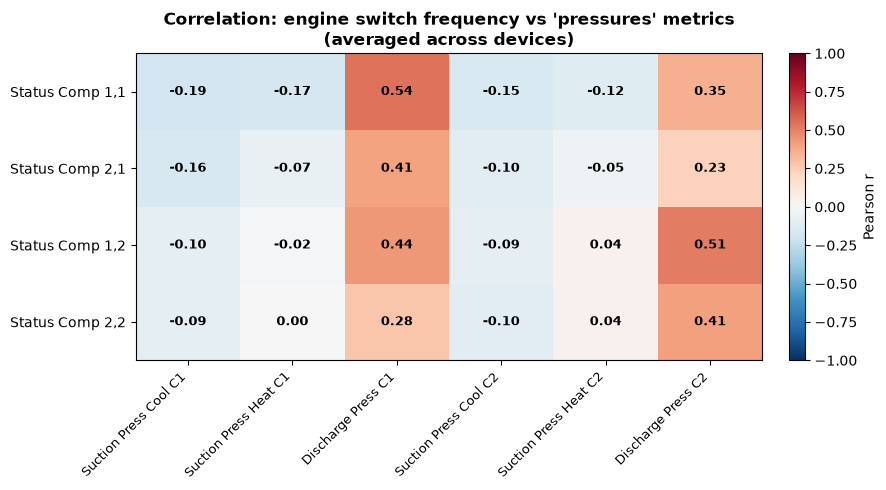

In [32]:
import pandas as pd
import numpy as np

engine_sensors_heatmap(pdf_corr, sensor_codes, selected_metrics)

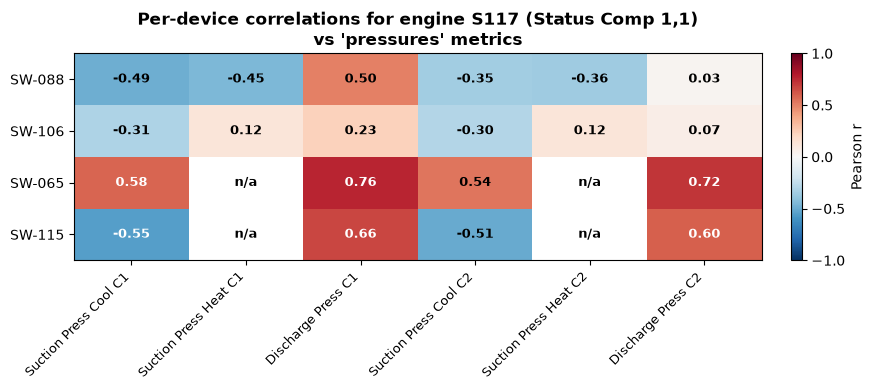

In [33]:
per_device_heatmap("S117", sensor_codes, selected_metrics, pdf_corr)

### Capacities metrics analysis

In [34]:
SELECTED_GROUP = "capacities"

In [35]:
# Pivot data
df_joined, selected_metrics, sensor_codes = engines_switch_counts_df(
    metric_groups, 
    SELECTED_GROUP, 
    target_metrics
)

Correlating each engine against group 'capacities':
  Sensors: ['S125', 'S181', 'S126', 'S43']



In [36]:
df_correlation = corr_df(sensor_codes, df_joined)

df_correlation.printSchema()

root
 |-- hwid: string (nullable = true)
 |-- corr_S117_vs_S125: double (nullable = true)
 |-- corr_S117_vs_S181: double (nullable = true)
 |-- corr_S117_vs_S126: double (nullable = true)
 |-- corr_S117_vs_S43: double (nullable = true)
 |-- corr_S118_vs_S125: double (nullable = true)
 |-- corr_S118_vs_S181: double (nullable = true)
 |-- corr_S118_vs_S126: double (nullable = true)
 |-- corr_S118_vs_S43: double (nullable = true)
 |-- corr_S169_vs_S125: double (nullable = true)
 |-- corr_S169_vs_S181: double (nullable = true)
 |-- corr_S169_vs_S126: double (nullable = true)
 |-- corr_S169_vs_S43: double (nullable = true)
 |-- corr_S170_vs_S125: double (nullable = true)
 |-- corr_S170_vs_S181: double (nullable = true)
 |-- corr_S170_vs_S126: double (nullable = true)
 |-- corr_S170_vs_S43: double (nullable = true)



In [37]:
pdf_corr = df_correlation.toPandas()

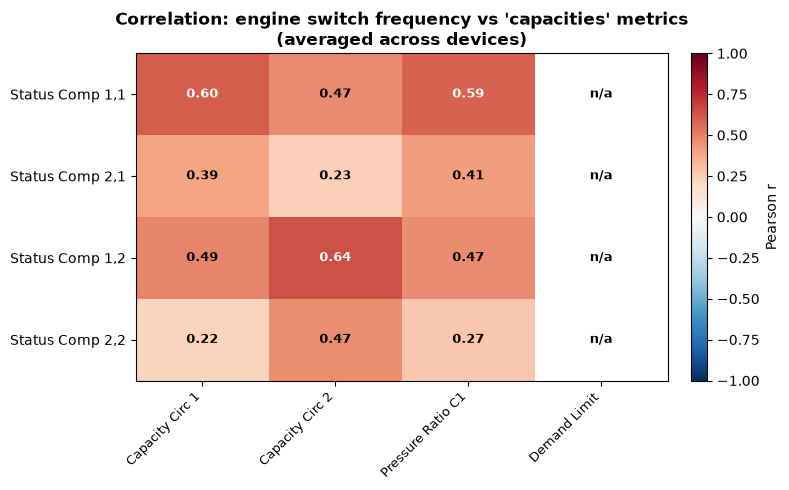

In [38]:

engine_sensors_heatmap(pdf_corr, sensor_codes, selected_metrics)

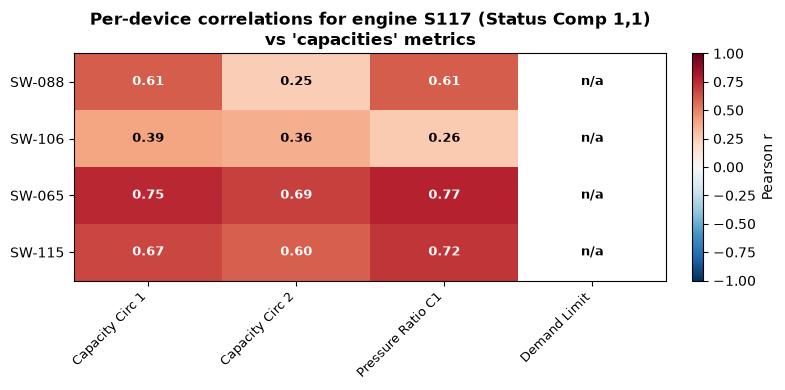

In [39]:
per_device_heatmap("S117", sensor_codes, selected_metrics, pdf_corr)

### Discharge metrics analysis

In [40]:
SELECTED_GROUP = "discharge_temps"

In [41]:
# Pivot data
df_joined, selected_metrics, sensor_codes = engines_switch_counts_df(
    metric_groups, 
    SELECTED_GROUP, 
    target_metrics
)

Correlating each engine against group 'discharge_temps':
  Sensors: ['S109', 'S110', 'S165', 'S166', 'S106', 'S107', 'S108', 'S163', 'S164']



In [42]:
df_correlation = corr_df(sensor_codes, df_joined)

In [43]:
pdf_corr = df_correlation.toPandas()

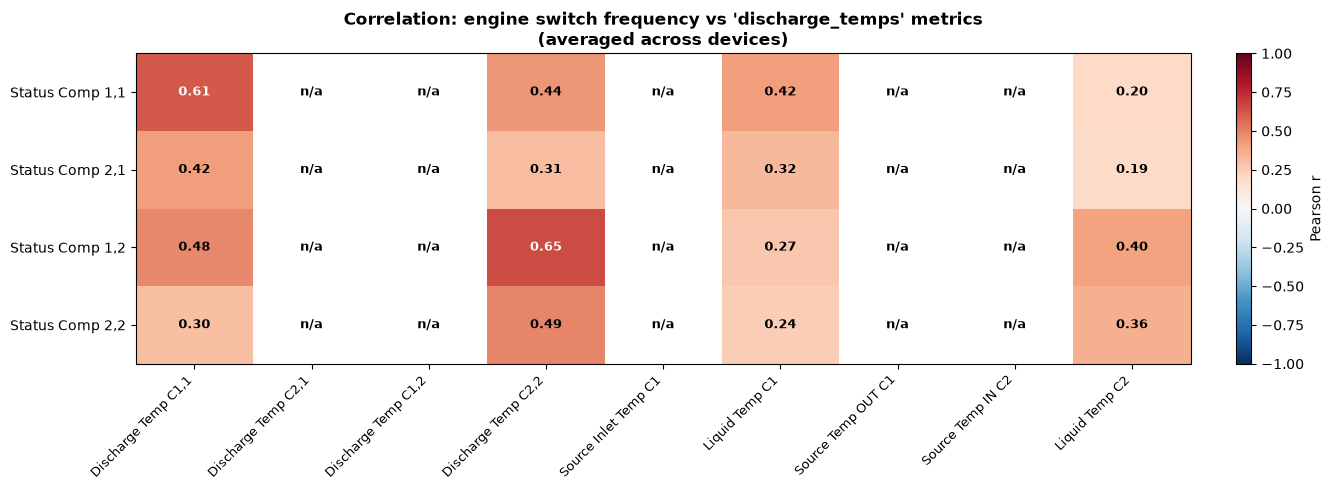

In [44]:

engine_sensors_heatmap(pdf_corr, sensor_codes, selected_metrics)

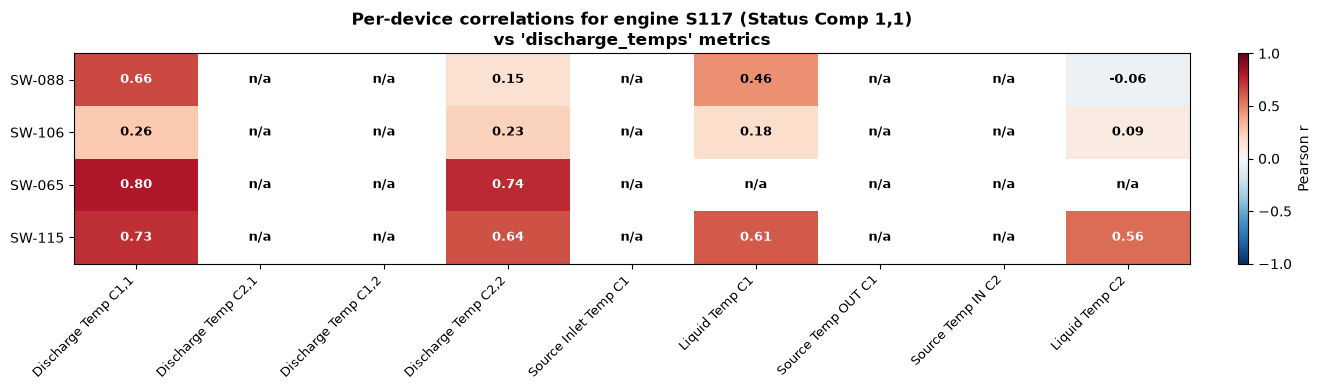

In [45]:
per_device_heatmap("S117", sensor_codes, selected_metrics, pdf_corr)

### Superheat metrics analysis

In [46]:
SELECTED_GROUP = "superheat_eev"

In [47]:
# Pivot data
df_joined, selected_metrics, sensor_codes = engines_switch_counts_df(
    metric_groups, 
    SELECTED_GROUP, 
    target_metrics
)

Correlating each engine against group 'superheat_eev':
  Sensors: ['S81', 'S83', 'S86', 'S90', 'S138', 'S140', 'S143']



In [48]:
df_correlation = corr_df(sensor_codes, df_joined)

In [49]:
pdf_corr = df_correlation.toPandas()

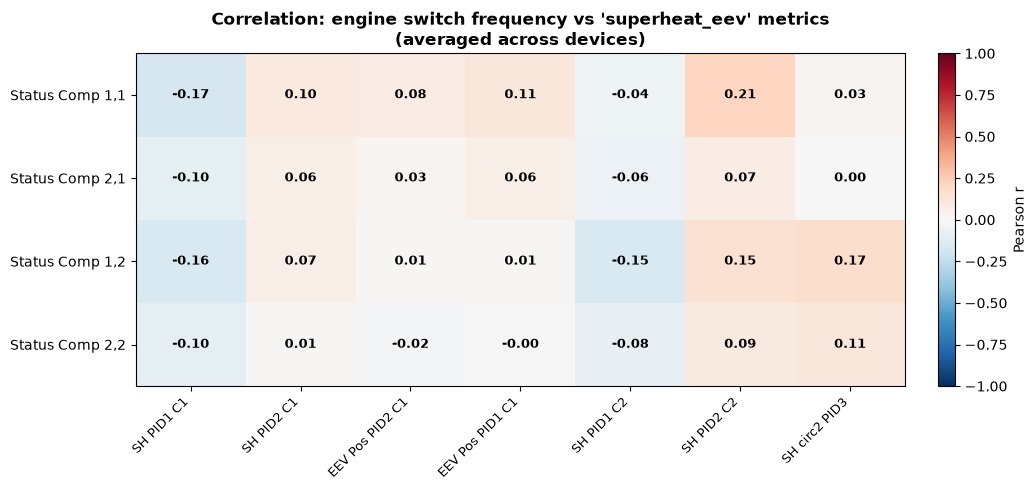

In [50]:

engine_sensors_heatmap(pdf_corr, sensor_codes, selected_metrics)

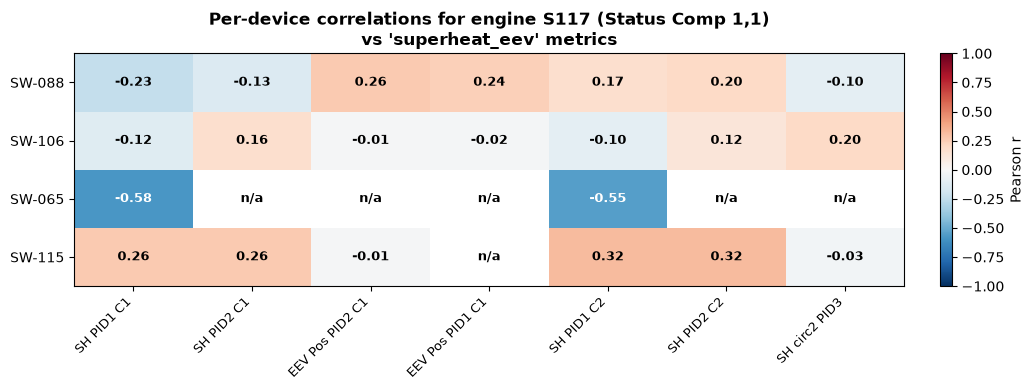

In [51]:
per_device_heatmap("S117", sensor_codes, selected_metrics, pdf_corr)

### Inverter & valve signals metrics analysis

In [52]:
SELECTED_GROUP = "signals_valves"

In [53]:
# Pivot data
df_joined, selected_metrics, sensor_codes = engines_switch_counts_df(
    metric_groups, 
    SELECTED_GROUP, 
    target_metrics
)

Correlating each engine against group 'signals_valves':
  Sensors: ['S19', 'S37', 'S69', 'S70', 'S122', 'S178', 'S42']



In [54]:
df_correlation = corr_df(sensor_codes, df_joined)

In [55]:
pdf_corr = df_correlation.toPandas()

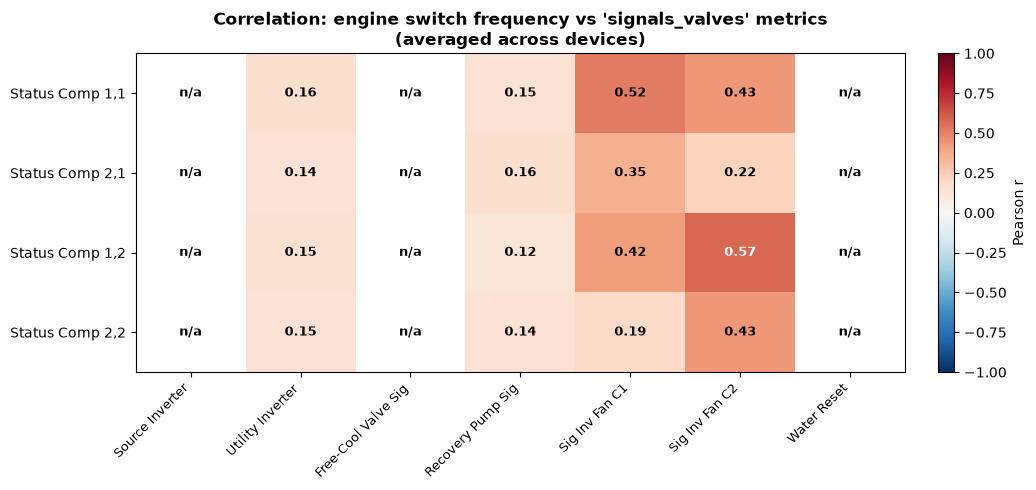

In [56]:

engine_sensors_heatmap(pdf_corr, sensor_codes, selected_metrics)

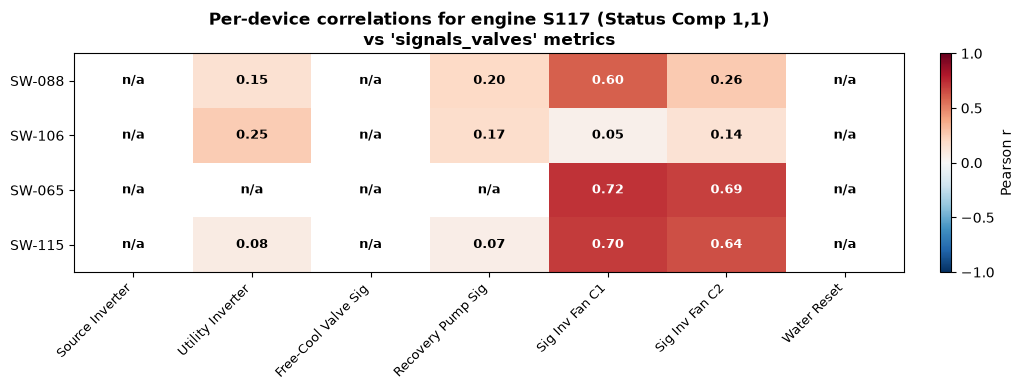

In [57]:
per_device_heatmap("S117", sensor_codes, selected_metrics, pdf_corr)

### Power & energy metrics analysis: Empty columns (?)

### Subcooling & misc metrics analysis

In [58]:
SELECTED_GROUP = "subcooling_misc"

In [59]:
# Pivot data
df_joined, selected_metrics, sensor_codes = engines_switch_counts_df(
    metric_groups, 
    SELECTED_GROUP, 
    target_metrics
)

Correlating each engine against group 'subcooling_misc':
  Sensors: ['S124', 'S180', 'S94', 'S97', 'S128', 'S129', 'S147', 'S151', 'S154']



In [60]:
df_correlation = corr_df(sensor_codes, df_joined)

In [61]:
pdf_corr = df_correlation.toPandas()

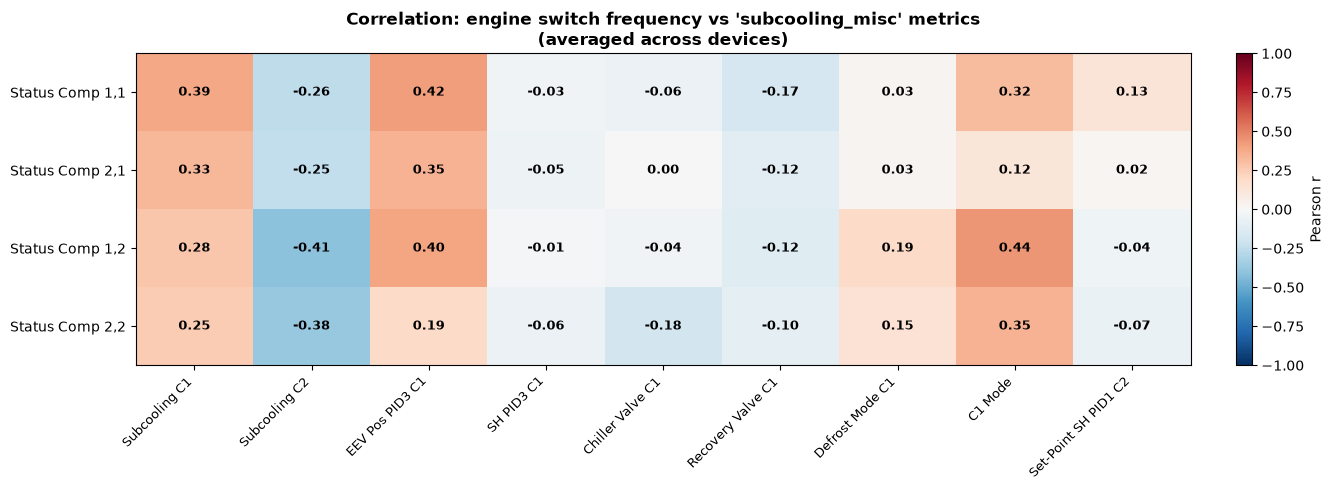

In [62]:

engine_sensors_heatmap(pdf_corr, sensor_codes, selected_metrics)

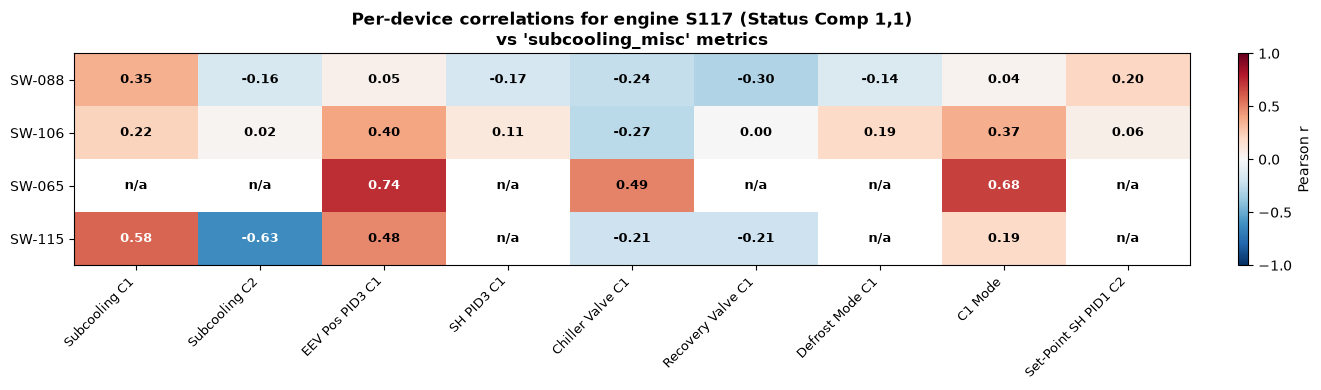

In [63]:
per_device_heatmap("S117", sensor_codes, selected_metrics, pdf_corr)

In [64]:
spark.stop()

## 4. Benchmark Results

The systematic distributed benchmarking of the correlation pipeline revealed key insights into Spark's execution model on the CloudVeneto cluster. Below is a detailed analysis of the main findings:

### 1. I/O-Bound Super-Linear Speedup
When scaling the cluster from 1 core (1 node) to 4 and 6 cores (3 nodes), the pipeline demonstrated a **super-linear parallel efficiency (>100%)**. 
This is mathematically confirmed by comparing the **Wall Time** (real elapsed time) with the **CPU Time** (actual processing time):
* **1 Core**: Wall Time ~53.5s vs CPU Time ~16.2s. 
* **6 Cores**: Wall Time ~6.4s vs CPU Time ~16.9s.

The CPU time remains constant across configurations (~16-17s), proving the computational load is consistent. However, the single-core setup suffers from massive **I/O Wait time (~37s)** due to resource starvation (network bandwidth limits reading from S3, local disk bottleneck for shuffle writes, and limited RAM causing disk spilling). 
Scaling horizontally to 3 nodes multiplied the available network and disk throughput, completely eliminating the I/O bottleneck and dropping execution time faster than pure CPU scaling would predict. This proves the workload at 1 core was heavily **I/O-Bound**.

### 2. Shuffle Partitions Optimization and AQE
Testing the pipeline across different `spark.sql.shuffle.partitions` (6, 12, 32, 200) revealed Spark's dynamic optimization capabilities. 
Despite requesting 200 partitions for a dataset with a very small shuffle size (~220 KB), the total scheduled tasks remained fixed at exactly 50 tasks across all configurations. 

This happens because **Adaptive Query Execution (AQE)** is enabled by default. AQE dynamically intercepts the shuffle phase and uses its `Coalesce Shuffle Partitions` feature to merge tiny partitions into larger, optimal ones. Spark recognized that creating 200 tasks for 220 KB of data would create excessive metadata overhead and perfectly coalesced the tasks to keep the 6 available cores fully occupied without wasting I/O.


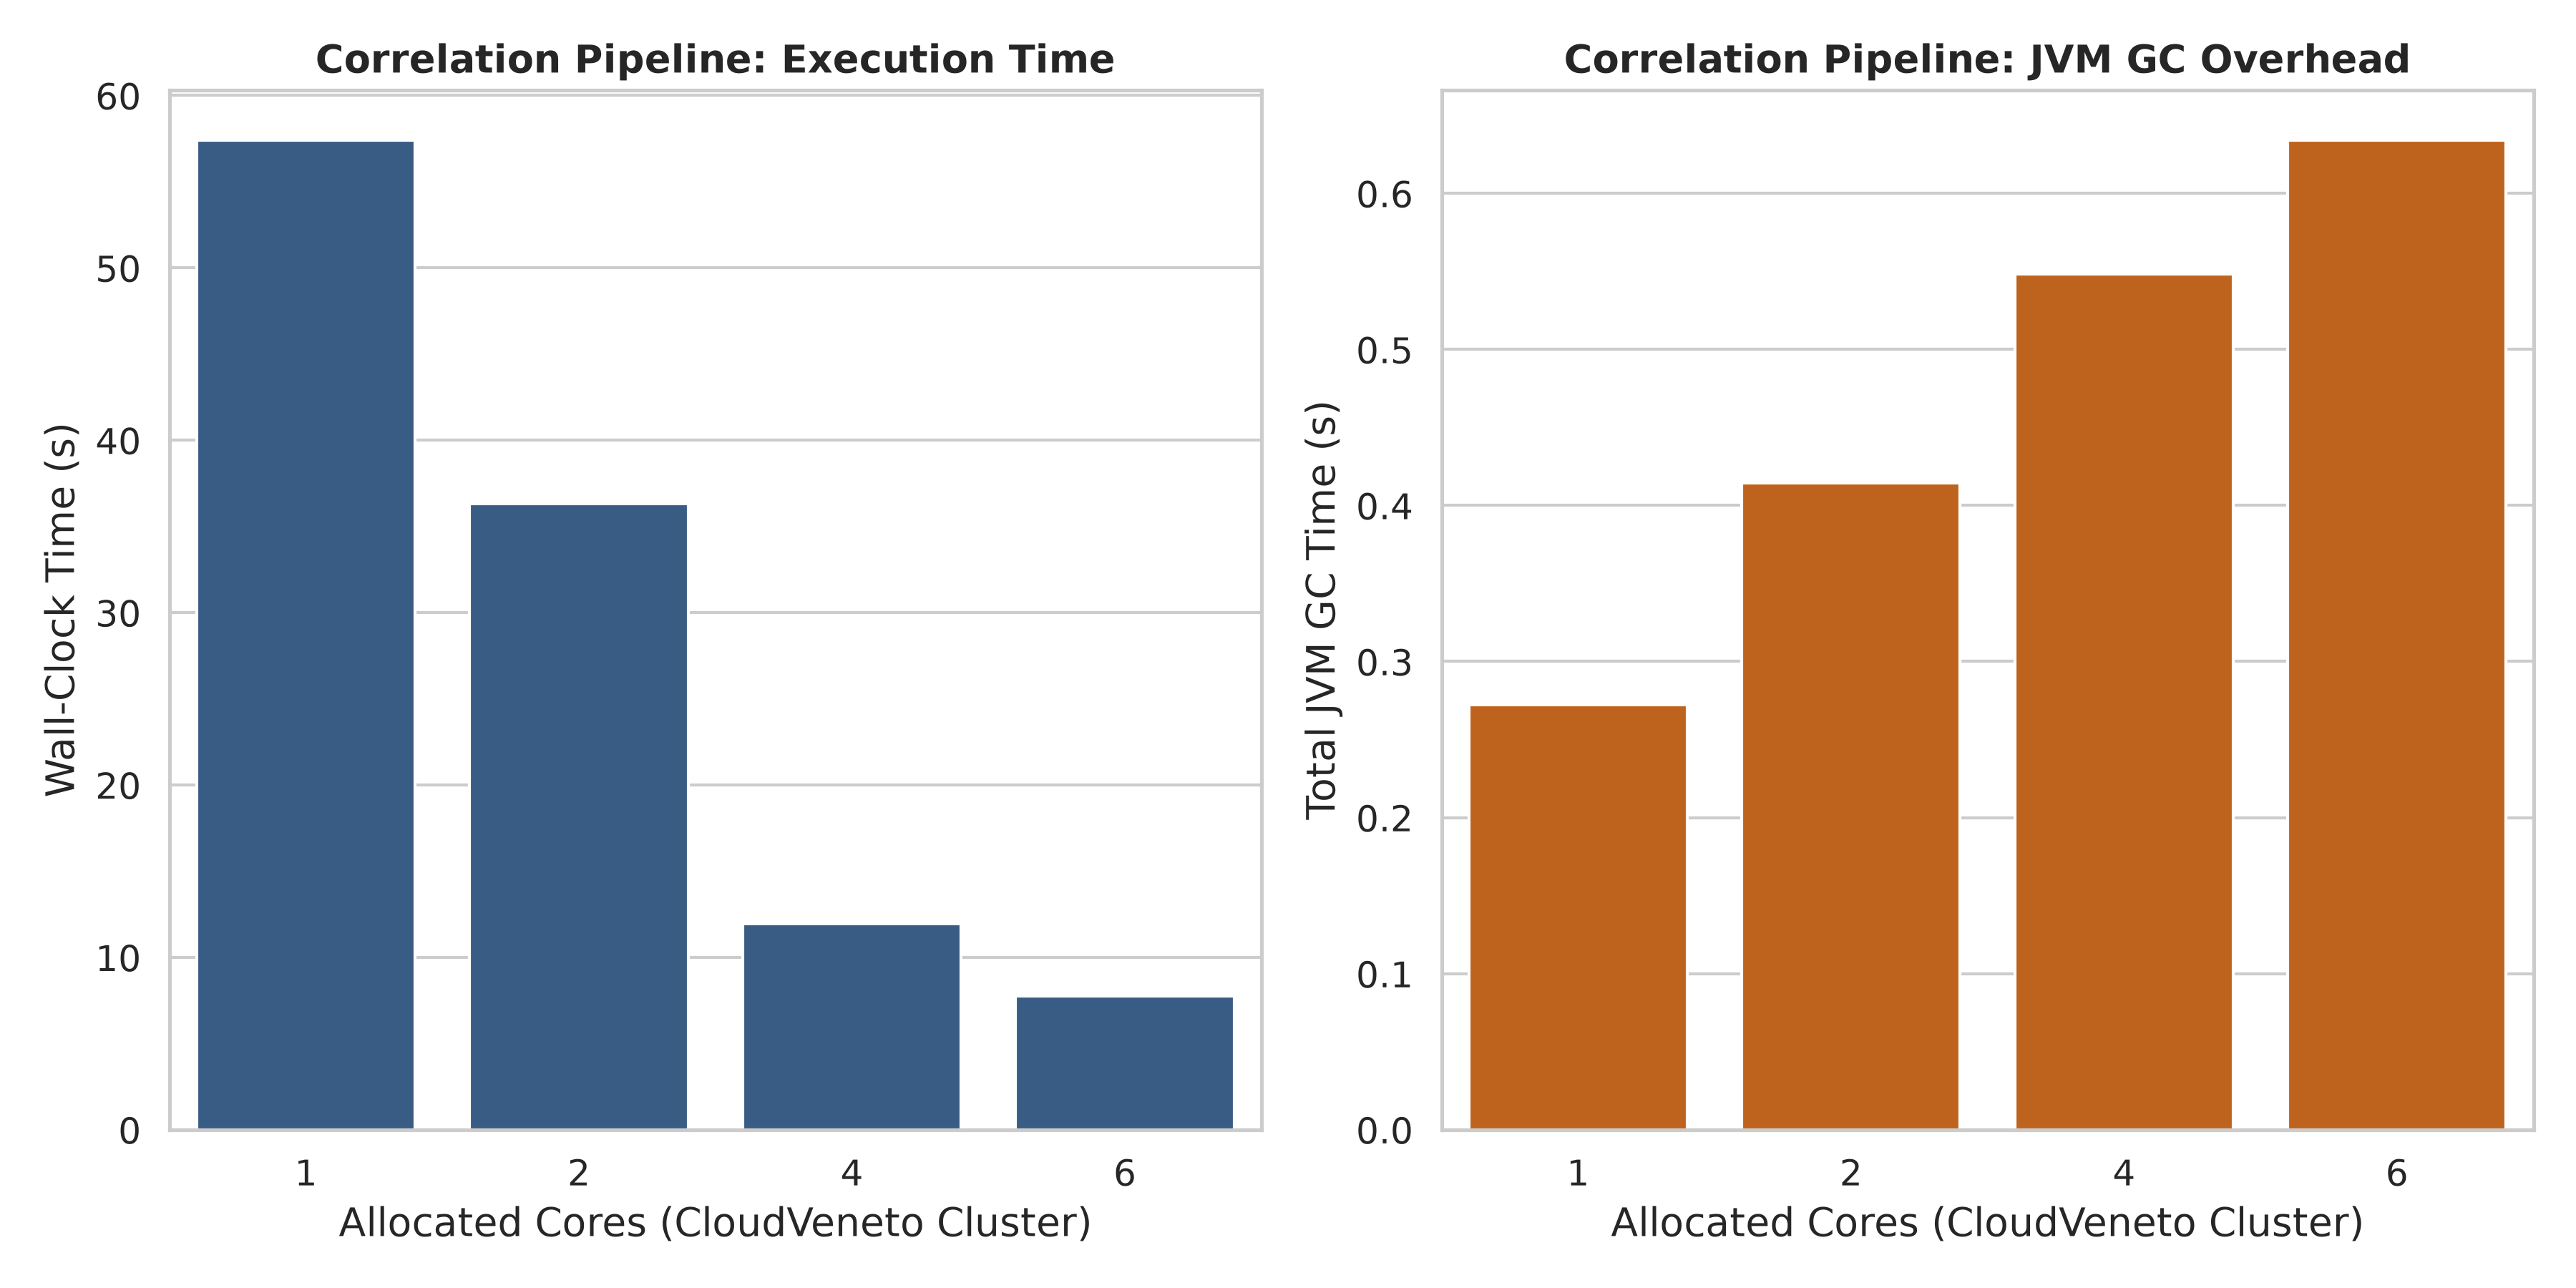

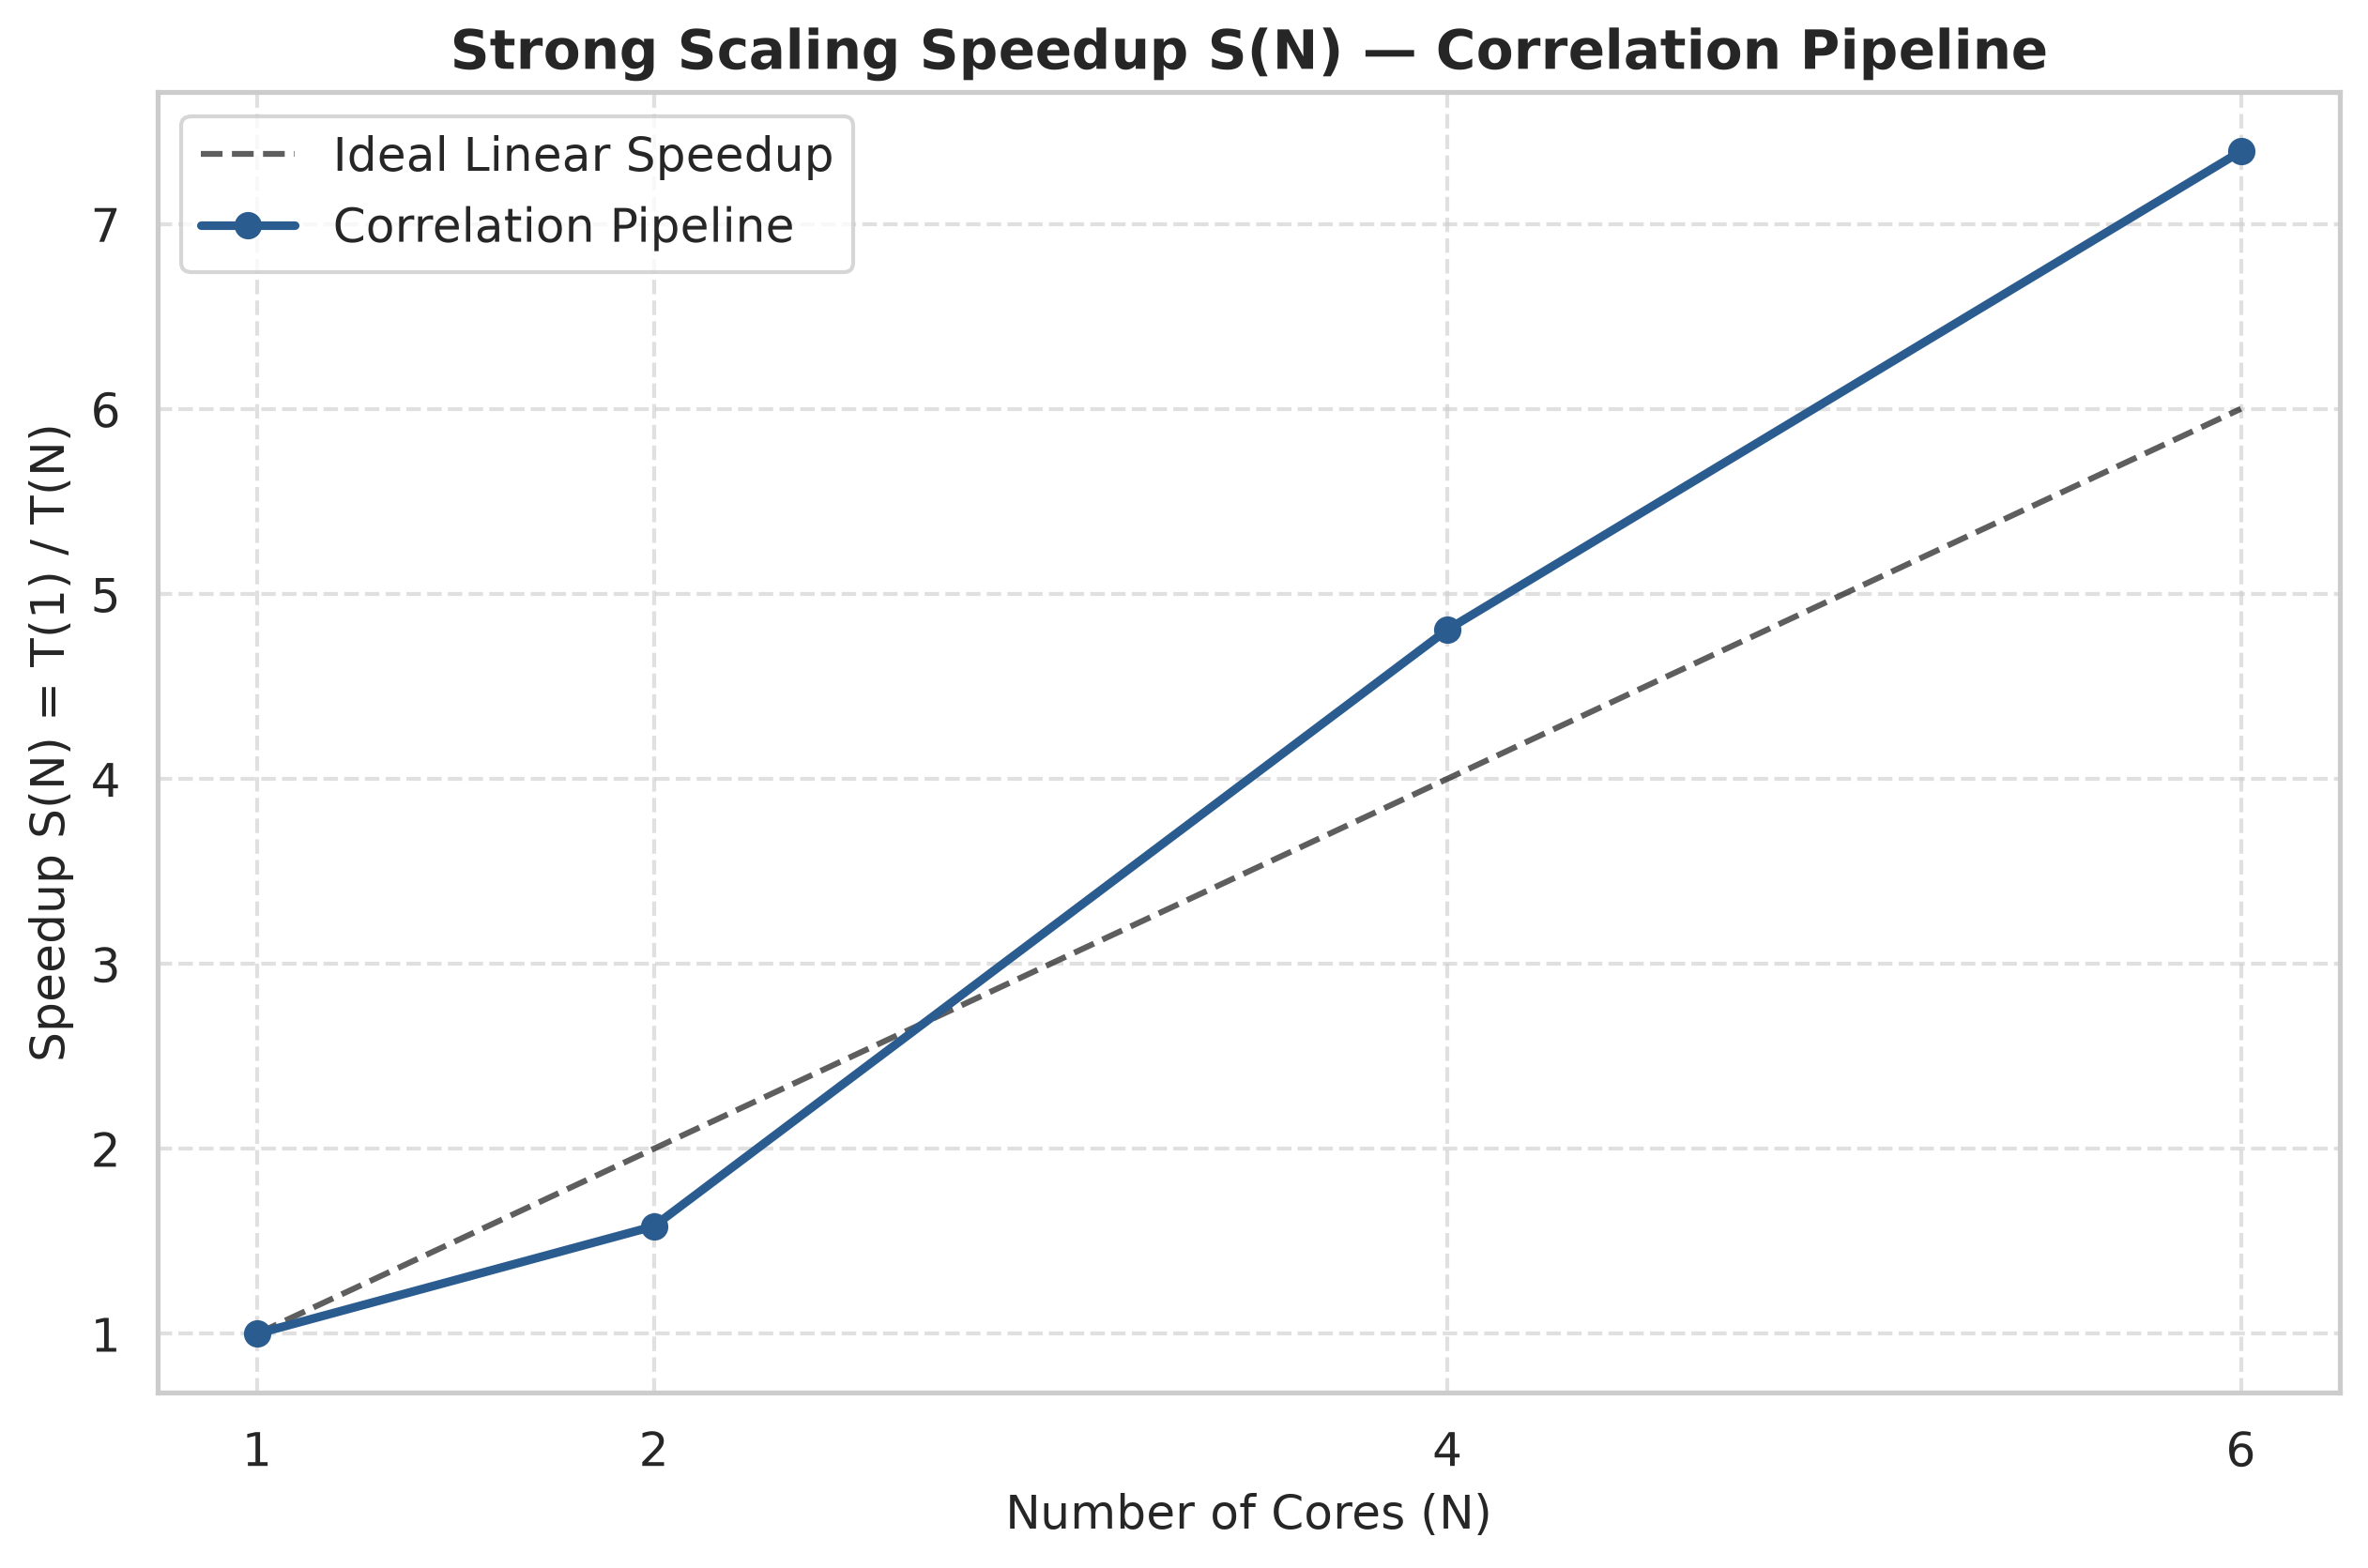

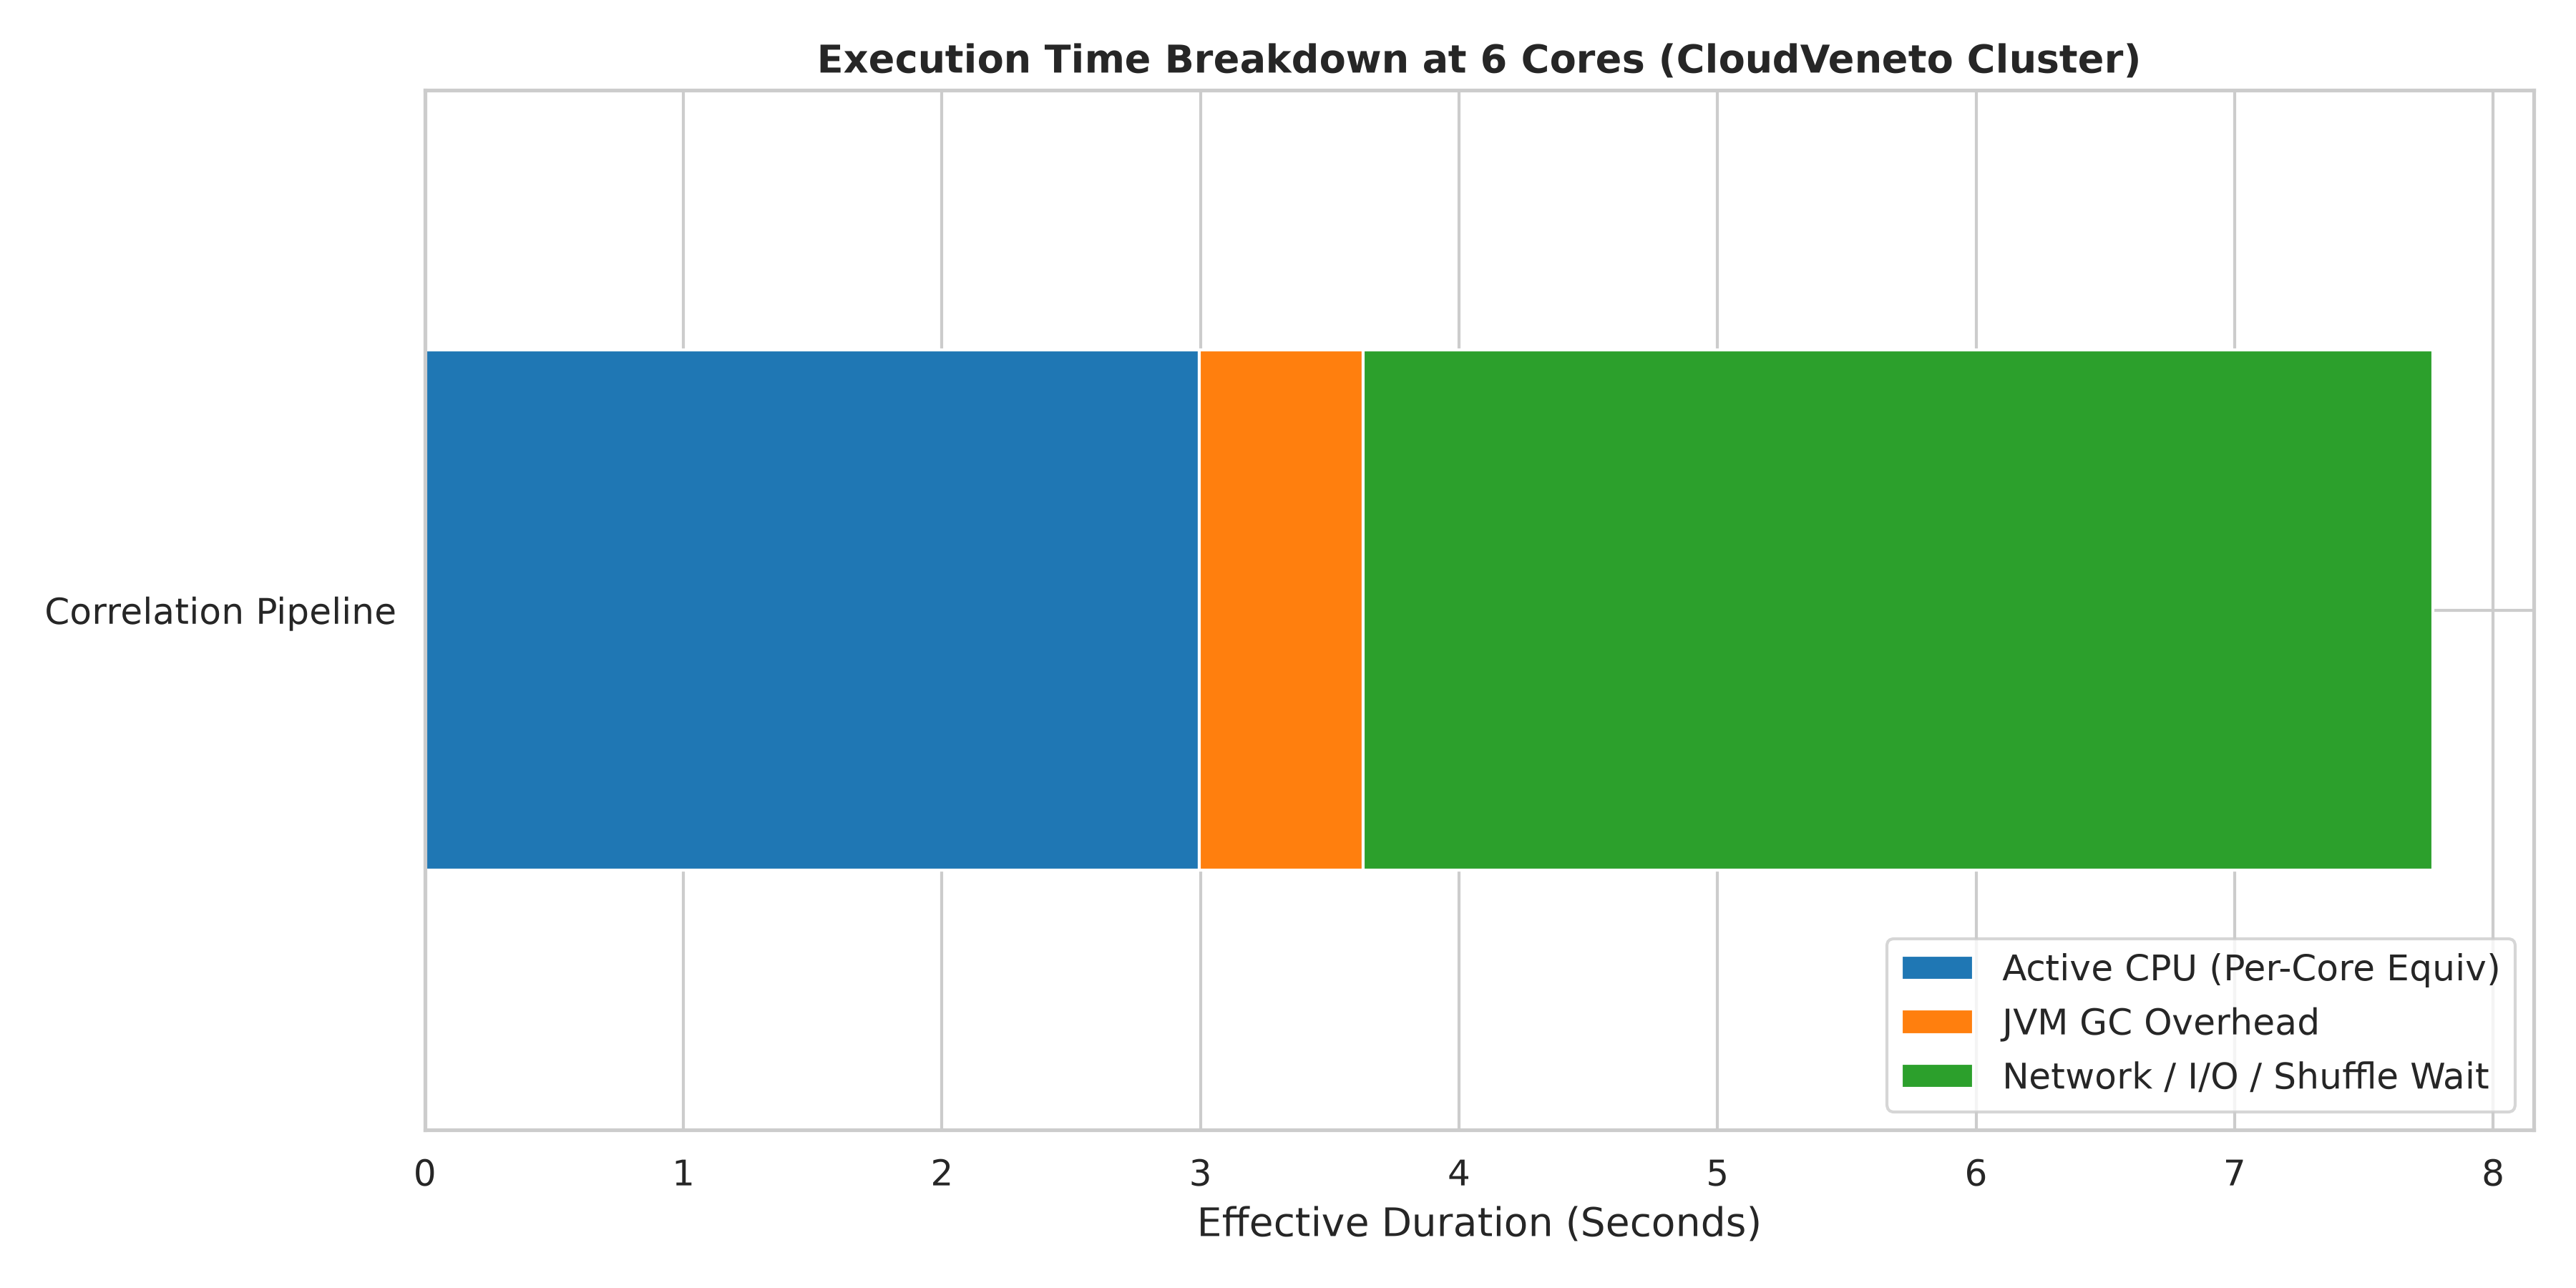

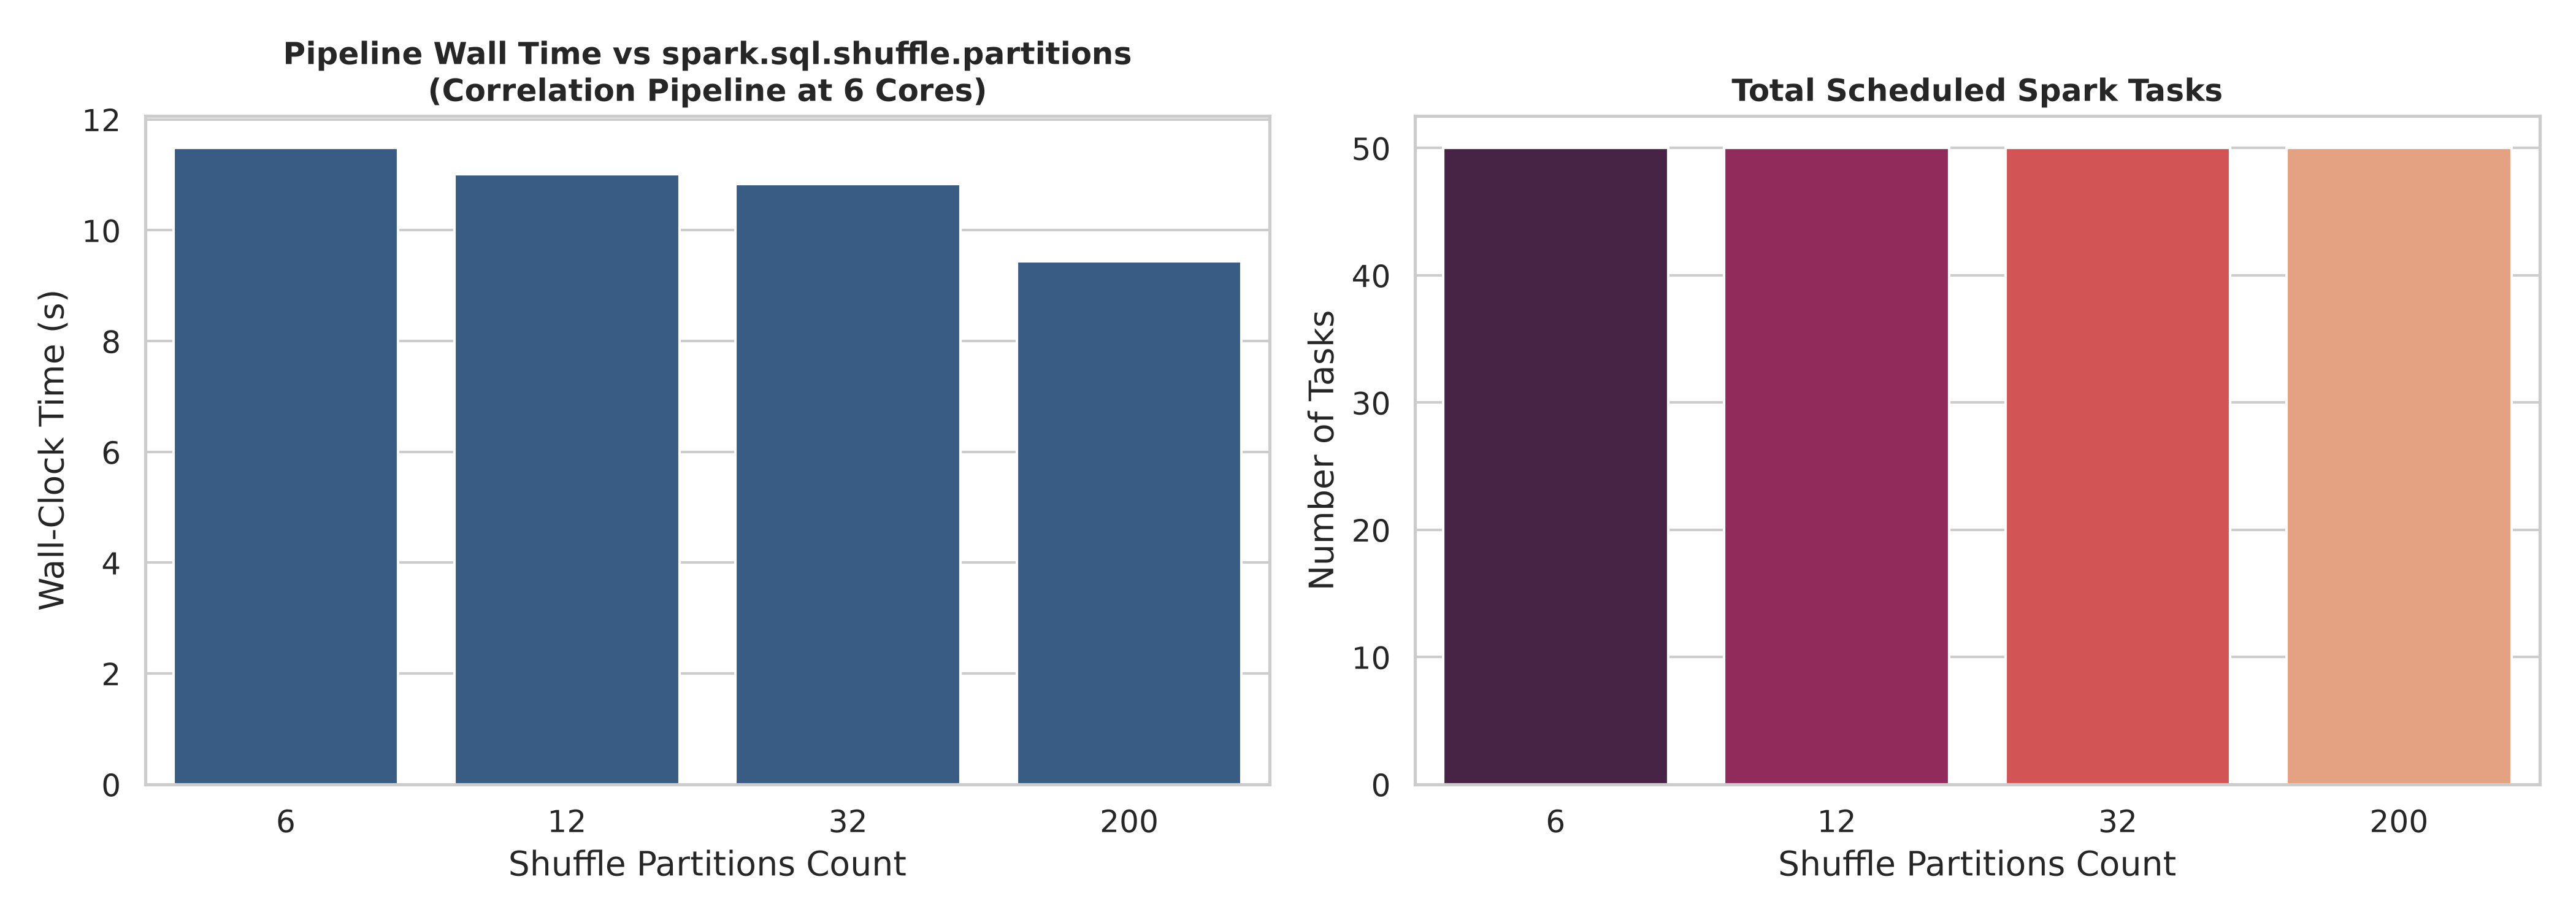

In [7]:
from IPython.display import Image, display

# Display Strong Scaling Benchmark Plots
display(Image(filename='Systematic_Distributed_Benchmarking/benchmark_plots/plot1_correlation_pipeline.png'))
display(Image(filename='Systematic_Distributed_Benchmarking/benchmark_plots/plot2_strong_scaling_speedup.png'))
display(Image(filename='Systematic_Distributed_Benchmarking/benchmark_plots/plot5_metrics_breakdown.png'))
display(Image(filename='Systematic_Distributed_Benchmarking/benchmark_plots/plot4_shuffle_partitions_tuning.png'))
